# DP9 - Sepsis Voorspelling

| | |
|---|---|
| **Opdrachtgever** | Isala Ziekenhuis Zwolle |
| **Data Scientist** | [Naam Student] |
| **Dataset** | Sepsis ICU dataset - Isala / Windesheim |
| **Opleverdatum** | [Datum] |

**Leertaken:**
* **AN1**           - Business Understanding
* **AN2**           - Data Understanding
* **RE1**           - Data Preperation
* **DN1 en RE2**    - Modeling
* **AD1**           - Evaluation
* **AD2**           - Deployment
* **MC1**           - Data mining
* **AD3**           - Ethiek & Maatschappij


---

## **AN1 - Business understanding**

### Businessvraag

#### Hoofdvraag
> Kunnen we op basis van klinische meetwaarden (vitale parameters en laboratoriumwaarden) vroegtijdig voorspellen of een IC-patiënt sepsis zal ontwikkelen?

#### Sub-doel: Fairness
Als onderdeel van de evaluatie wordt onderzocht in hoeverre het model gelijk presteert voor verschillende patiëntgroepen (leeftijd en geslacht), en wat de ethische implicaties zijn van eventuele prestatieverschillen.

### Aanleiding:

Sepsis is een levensbedreigende aandoening waarbij het lichaam overmatig reageert op een infectie, wat kan leiden tot orgaanfalen en overlijden. Jaarlijks overlijden wereldwijd meer dan 11 miljoen mensen aan sepsis. In Nederland worden jaarlijks tienduizenden patiënten opgenomen met sepsis, waarvan een significant deel op de Intensive Care (IC). Vroegtijdige herkenning en behandeling is de sleutel tot overleving: elke vertraging van één uur in de behandeling verhoogt de sterfte significant.

Het Isala ziekenhuis in Zwolle heeft als één van de grotere perifere ziekenhuizen van Nederland een drukbezette IC-afdeling. Verpleegkundigen en artsen monitoren continu tientallen vitale parameters en laboratoriumwaarden per patiënt. Het handmatig herkennen van vroegtijdige sepsissignalen in al deze data is een uitdagende taak, zeker bij hoge werkdruk.

Een voorspellend model dat automatisch en continu de kans op sepsis berekent op basis van beschikbare meetwaarden, kan het klinische personeel ondersteunen om eerder in te grijpen. Dit kan levens redden en ziekenhuisopnames verkorten.

### Datavraag
> Kan een classificatiemodel, getraind op klinische features (vitale parameters en laboratoriumwaarden) per uur, voorspellen of een patiënt in de komende uren sepsis ontwikkelt (SepsisLabel = 1)?

### Organisatorische context

Dit onderzoek wordt uitgevoerd in het kader van de differentiatieopdracht Data Science voor Hogeschool Windesheim, in samenwerking met het Isala Ziekenhuis te Zwolle. Het Isala is een topklinisch opleidingsziekenhuis met een grote IC-afdeling. Het model is bedoeld als decision support tool voor IC-verpleegkundigen en -artsen: het signaleert risicovolle patiënten, waarna de behandelaar zelf de beslissing neemt.

### Maatschappelijke context

* **Patiëntveiligheid:** Sepsis heeft een hoge mortaliteit. Een eerder en betrouwbaarder signaleringsmodel kan directe levensreddende impact hebben voor IC-patiënten.
* **Werkdruk zorgpersoneel:** IC-personeel opereert onder hoge werkdruk. Een AI-ondersteund vroegwaarschuwingssysteem kan prioritering in zorgverlening ondersteunen zonder het klinisch oordeel te vervangen.
* **Fairness:** Het model wordt getraind op data van patiënten met wisselende leeftijden en geslachten. Als het model systematisch slechter presteert voor bepaalde groepen (bijvoorbeeld oudere patiënten of vrouwen), kan dit leiden tot ongelijke zorg. Dit wordt expliciet geanalyseerd als sub-doel van dit onderzoek.
* **Privacy:** De gebruikte dataset bevat geanonimiseerde medische gegevens. In een echte ziekenhuisomgeving zijn medische gegevens bijzondere persoonsgegevens (AVG Artikel 9) en vereist verwerking een expliciete juridische grondslag.
* **Automation bias:** Er bestaat een risico dat zorgverleners te veel vertrouwen op de modeluitkomst en hun eigen klinisch oordeel minder inzetten. Het model dient uitdrukkelijk als ondersteuning, niet als vervanging.
* **Klasse-onbalans:** Slechts ~1,8% van de observaties in de dataset heeft een sepsislabel. Een model dat altijd 0 voorspelt behaalt al 98,2% accuracy, wat misleidend is. Dit vraagt om specifieke evaluatiemetrics.

### Juridische implicaties

* **AVG Artikel 9 – Bijzondere persoonsgegevens:** Medische gegevens zijn bijzondere persoonsgegevens. Verwerking is in principe verboden, tenzij aan strikte voorwaarden is voldaan (o.a. expliciete toestemming of wetenschappelijk onderzoek met adequate waarborgen). De gebruikte dataset is voor dit onderzoek geanonimiseerd en valt daarmee buiten de directe werking van de AVG.
* **AI Act – Hoog risico:** Medische AI-systemen die worden ingezet voor diagnose of behandelbeslissingen vallen onder de hoog-risicocategorie van de EU AI Act (Annex III). Dit betekent dat bij daadwerkelijke inzet in het ziekenhuis eisen gelden op het gebied van transparantie, robuustheid, menselijk toezicht en documentatie.
* **MDR (Medical Device Regulation):** Software die wordt gebruikt voor klinische besluitvorming kan kwalificeren als medisch hulpmiddel en valt dan onder de EU MDR-regelgeving, inclusief CE-markering.

### Stakeholders

* **Isala Ziekenhuis Zwolle** – Opdrachtgever
* **IC-verpleegkundigen en intensivisten** – Eindgebruikers van het model
* **IC-patiënten** – Degenen wiens zorg direct beïnvloed wordt
* **Hogeschool Windesheim** – Onderwijsinstelling en begeleidende partij
* **Ethische commissie ziekenhuis** – Toetst inzet van AI in klinische praktijk

### KSF & KPI's

**KSF**  
Ontwikkeling van een model dat vroegtijdig en betrouwbaar sepsis kan signaleren bij IC-patiënten op basis van klinische meetwaarden.

**KPI's**
* Een **AUROC ≥ 0.80** behalen op de testset
* Een **recall (sensitivity) ≥ 0.70** voor de klasse `SepsisLabel = 1` (sepsis detecteren is kritisch)
* **Precision ≥ 0.30** voor de klasse `SepsisLabel = 1` (te veel fout-positieven belasten het personeel)
* Het verschil in AUROC tussen geslachten en leeftijdsgroepen kleiner dan **0.05** (fairness sub-doel)

### Databron

De gebruikte dataset is afkomstig van de Isala opdracht aangeboden via Hogeschool Windesheim. De dataset bevat per patiënt per uur gemeten klinische parameters gedurende het IC-verblijf. De trainset bevat **1.399.302 observaties** van **36.336 unieke patiënten**. De testset bevat **152.908 observaties** van **4.000 unieke patiënten** (zonder sepsislabel).

Beschikbare features:
* **Vitale parameters:** HR, O2Sat, Temp, SBP, MAP, DBP, Resp, EtCO2
* **Laboratoriumwaarden:** BaseExcess, HCO3, FiO2, pH, PaCO2, SaO2, AST, BUN, Alkalinephos, Calcium, Chloride, Creatinine, Bilirubin_direct, Glucose, Lactate, Magnesium, Phosphate, Potassium, Bilirubin_total, TroponinI, Hct, Hgb, PTT, WBC, Fibrinogen, Platelets
* **Patiëntkenmerken:** Age, Gender, Unit1, Unit2, HospAdmTime, ICULOS
* **Target:** SepsisLabel (0 = geen sepsis, 1 = sepsis)

## **AN2 - Data Understanding**

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, f1_score, precision_score, recall_score,
    average_precision_score, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
from pathlib import Path

In [26]:
# === Inladen datasets ===
df_train = pd.read_csv('train_data.csv')
df_test  = pd.read_csv('test_data.csv')

print(f'Trainset: {df_train.shape[0]:,} rijen, {df_train.shape[1]} kolommen')
print(f'Testset:  {df_test.shape[0]:,} rijen, {df_test.shape[1]} kolommen')
df_train.head(10)

Trainset: 1,399,302 rijen, 44 kolommen
Testset:  152,908 rijen, 43 kolommen


,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,1,0,17072
1,1,1,65.0,100.0,NaN,NaN,72.0,NaN,16.5,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,2,0,17072
2,2,2,78.0,100.0,NaN,NaN,42.5,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,3,0,17072
3,3,3,73.0,100.0,NaN,NaN,NaN,NaN,17.0,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,4,0,17072
4,4,4,70.0,100.0,NaN,129.0,74.0,69.0,14.0,NaN,...,NaN,330.0,68.54,0,NaN,NaN,-0.02,5,0,17072
5,5,5,62.0,100.0,NaN,124.0,85.0,61.0,14.0,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,6,0,17072
6,6,6,61.0,100.0,NaN,101.0,75.0,58.0,14.0,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,7,0,17072
7,7,7,68.0,100.0,35.78,142.0,93.5,78.0,16.0,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,8,0,17072
8,8,8,71.0,100.0,NaN,121.0,74.0,91.0,14.0,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,9,0,17072
9,9,9,69.0,100.0,NaN,120.0,79.0,98.0,14.0,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,10,0,17072


In de eerste tien rijen is al te zien dat de dataset veel missende waarden bevat, vooral bij laboratoriumwaarden. Dit is klinisch logisch: labtests worden niet elk uur afgenomen.

In [27]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1399302 entries, 0 to 1399301
Data columns (total 44 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Unnamed: 0        1399302 non-null  int64  
 1   Hour              1399302 non-null  int64  
 2   HR                1261070 non-null  float64
 3   O2Sat             1216615 non-null  float64
 4   Temp              474304 non-null   float64
 5   SBP               1195492 non-null  float64
 6   MAP               1225052 non-null  float64
 7   DBP               961600 non-null   float64
 8   Resp              1184880 non-null  float64
 9   EtCO2             52020 non-null    float64
 10  BaseExcess        76344 non-null    float64
 11  HCO3              58809 non-null    float64
 12  FiO2              117251 non-null   float64
 13  pH                97571 non-null    float64
 14  PaCO2             78284 non-null    float64
 15  SaO2              48409 non-null    float64
 16  AST        

In [28]:
df_train.describe()

,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
count,1.399302e+06,1.399302e+06,1.261070e+06,1.216615e+06,474304.000000,1.195492e+06,1.225052e+06,961600.000000,1.184880e+06,52020.000000,...,9319.000000,83243.000000,1.399302e+06,1.399302e+06,848885.000000,848885.000000,1.399294e+06,1.399302e+06,1.399302e+06,1.399302e+06
mean,2.551103e+01,2.551103e+01,8.459206e+01,9.719306e+01,36.977555,1.237281e+02,8.239274e+01,63.795128,1.873619e+01,32.925865,...,287.729520,195.940093,6.199812e+01,5.604073e-01,0.496395,0.503605,-5.614702e+01,2.700756e+01,1.821051e-02,5.917730e+04
std,2.884830e+01,2.884830e+01,1.734384e+01,2.945582e+00,0.773453,2.320404e+01,1.634168e+01,13.945080,5.098782e+00,7.931398,...,153.426372,104.158390,1.639975e+01,4.963377e-01,0.499987,0.499987,1.656790e+02,2.894534e+01,1.337120e-01,5.022381e+04
min,0.000000e+00,0.000000e+00,2.000000e+01,2.000000e+01,20.900000,2.000000e+01,2.000000e+01,20.000000,1.000000e+00,10.000000,...,34.000000,1.000000,1.400000e+01,0.000000e+00,0.000000,0.000000,-5.366860e+03,1.000000e+00,0.000000e+00,1.000000e+00
25%,9.000000e+00,9.000000e+00,7.200000e+01,9.600000e+01,36.500000,1.070000e+02,7.100000e+01,54.000000,1.500000e+01,28.000000,...,184.000000,126.000000,5.172000e+01,0.000000e+00,0.000000,0.000000,-4.675000e+01,1.100000e+01,0.000000e+00,9.996000e+03
50%,1.900000e+01,1.900000e+01,8.350000e+01,9.800000e+01,37.000000,1.210000e+02,8.000000e+01,62.000000,1.800000e+01,33.000000,...,251.000000,180.000000,6.400000e+01,1.000000e+00,0.000000,1.000000,-6.030000e+00,2.100000e+01,0.000000e+00,1.996200e+04
75%,3.300000e+01,3.300000e+01,9.600000e+01,9.950000e+01,37.500000,1.380000e+02,9.200000e+01,72.000000,2.150000e+01,38.000000,...,349.000000,244.000000,7.400000e+01,1.000000e+00,1.000000,1.000000,-4.000000e-02,3.400000e+01,0.000000e+00,1.098270e+05
max,3.350000e+02,3.350000e+02,2.800000e+02,1.000000e+02,50.000000,3.000000e+02,3.000000e+02,300.000000,1.000000e+02,100.000000,...,1760.000000,2322.000000,1.000000e+02,1.000000e+00,1.000000,1.000000,2.399000e+01,3.360000e+02,1.000000e+00,1.200000e+05


### Klasse-verdeling (SepsisLabel)

=== Klasse-verdeling SepsisLabel ===
Geen sepsis (0):  1,373,820  (98.18%)
Sepsis     (1):     25,482  (1.82%)
Verhouding 0:1 = 53:1


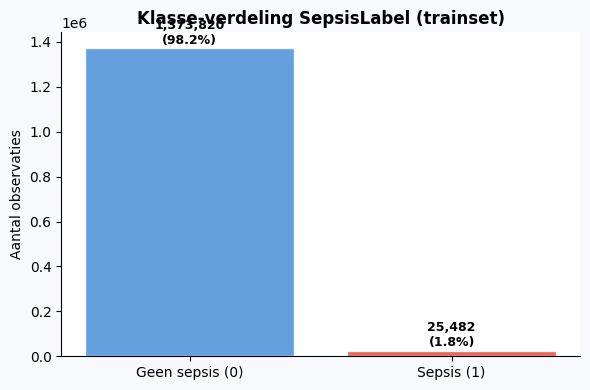

In [29]:
label_counts = df_train['SepsisLabel'].value_counts()
label_pct    = df_train['SepsisLabel'].value_counts(normalize=True).round(4) * 100

print('=== Klasse-verdeling SepsisLabel ===')
print(f'Geen sepsis (0): {label_counts[0]:>10,}  ({label_pct[0]:.2f}%)')
print(f'Sepsis     (1): {label_counts[1]:>10,}  ({label_pct[1]:.2f}%)')
print(f'Verhouding 0:1 = {label_counts[0]//label_counts[1]}:1')

fig, ax = plt.subplots(figsize=(6, 4), facecolor='#f7f9fc')
bars = ax.bar(['Geen sepsis (0)', 'Sepsis (1)'], label_counts.values,
              color=['#4a90d9', '#e74c3c'], edgecolor='white', alpha=0.85)
for bar, val, pct in zip(bars, label_counts.values, label_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Klasse-verdeling SepsisLabel (trainset)', fontsize=12, fontweight='bold')
ax.set_ylabel('Aantal observaties')
ax.set_facecolor('white')
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

Er is een sterke **klasse-onbalans**: slechts 1,82% van de observaties heeft een sepsislabel. Een naïef model dat altijd 0 voorspelt behaalt al 98,18% accuracy. Dit maakt accuracy een ongeschikte metric; we focussen op AUROC, recall en precision.

### Missende waarden

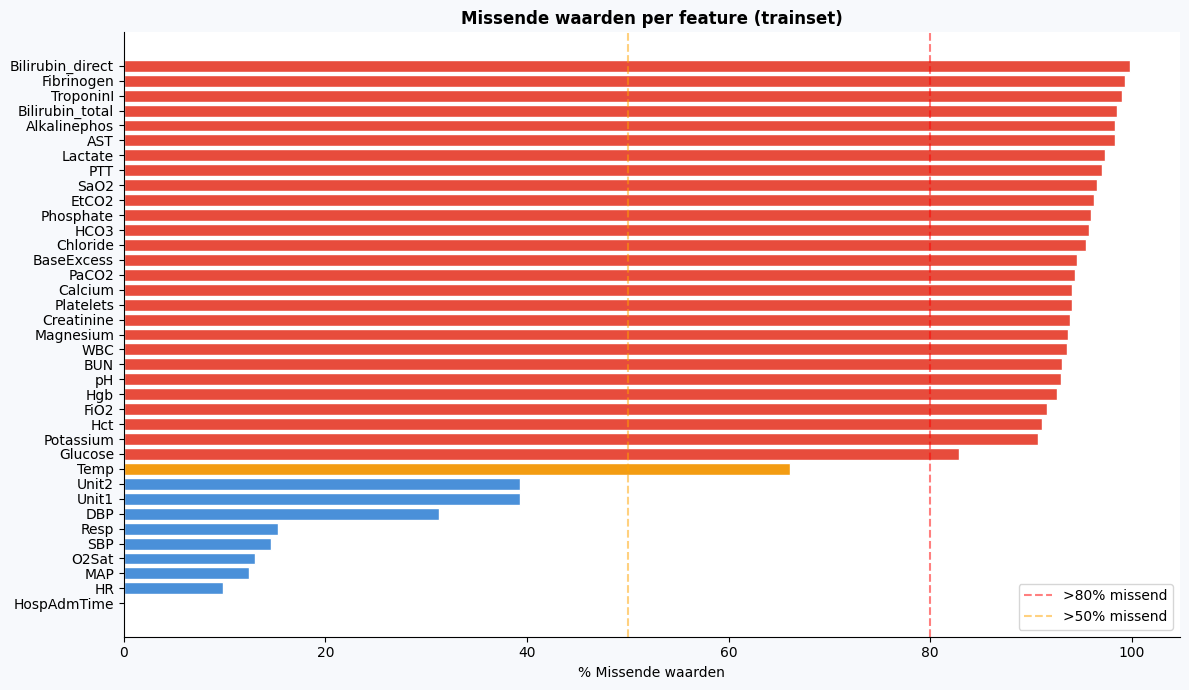

Features met >80% missend: 27
Features met >50% missend: 28
Features zonder missende waarden: 7


In [30]:
missing = (df_train.isnull().sum() / len(df_train) * 100).sort_values(ascending=False)
missing_df = missing[missing > 0].reset_index()
missing_df.columns = ['Feature', 'Missing (%)']

fig, ax = plt.subplots(figsize=(12, 7), facecolor='#f7f9fc')
colors = ['#e74c3c' if v > 80 else '#f39c12' if v > 50 else '#4a90d9' 
          for v in missing_df['Missing (%)']]
ax.barh(missing_df['Feature'][::-1], missing_df['Missing (%)'][::-1],
        color=colors[::-1], edgecolor='white')
ax.axvline(x=80, color='red', linestyle='--', alpha=0.5, label='>80% missend')
ax.axvline(x=50, color='orange', linestyle='--', alpha=0.5, label='>50% missend')
ax.set_xlabel('% Missende waarden')
ax.set_title('Missende waarden per feature (trainset)', fontsize=12, fontweight='bold')
ax.legend()
ax.set_facecolor('white')
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

print(f'Features met >80% missend: {(missing > 80).sum()}')
print(f'Features met >50% missend: {(missing > 50).sum()}')
print(f'Features zonder missende waarden: {(missing == 0).sum()}')

De meeste laboratoriumwaarden hebben een hoog percentage missende waarden. Dit is klinisch realistisch: laboratoriumtests worden niet elk uur afgenomen. Vitale parameters (HR, O2Sat, SBP, MAP, Resp) hebben minder missende waarden en worden continu gemonitord.

### Distributie vitale parameters

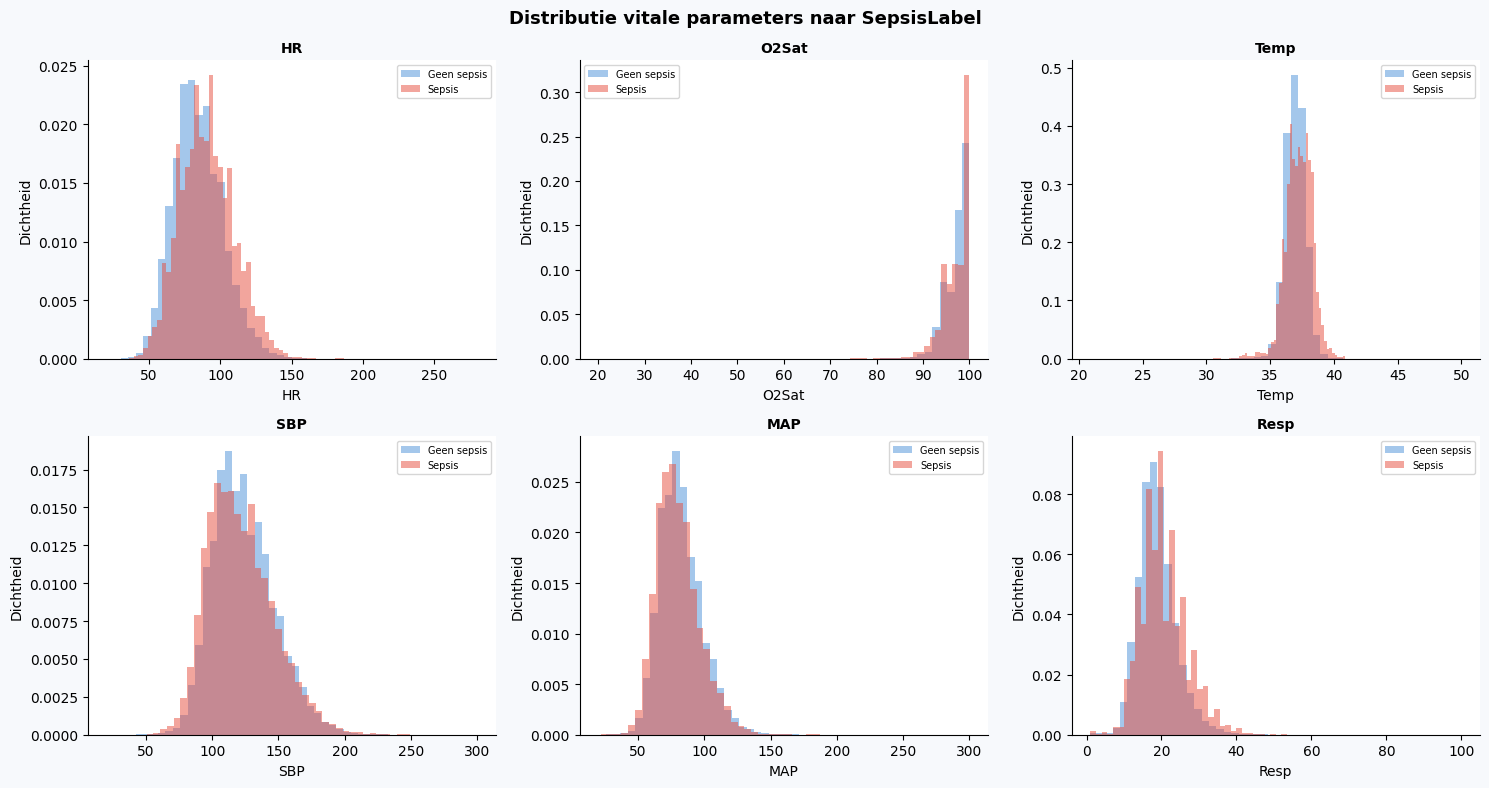

In [31]:
vital_cols = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'Resp']

fig, axes = plt.subplots(2, 3, figsize=(15, 8), facecolor='#f7f9fc')
fig.suptitle('Distributie vitale parameters naar SepsisLabel', fontsize=13, fontweight='bold')

for ax, col in zip(axes.flatten(), vital_cols):
    for label, color, name in [(0, '#4a90d9', 'Geen sepsis'), (1, '#e74c3c', 'Sepsis')]:
        data = df_train[df_train['SepsisLabel'] == label][col].dropna()
        ax.hist(data, bins=50, alpha=0.5, color=color, label=name, density=True)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Dichtheid')
    ax.legend(fontsize=7)
    ax.set_facecolor('white')
    for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

Er zijn kleine maar zichtbare verschuivingen in de distributies tussen sepsis- en niet-sepsis patiënten. Bij hartslag (HR) en ademfrequentie (Resp) zijn hogere waarden te zien bij sepsispatiënten, wat klinisch verwacht is (tachycardie en tachypneu zijn sepsis criteria).

### Patiëntkenmerken: leeftijd en geslacht

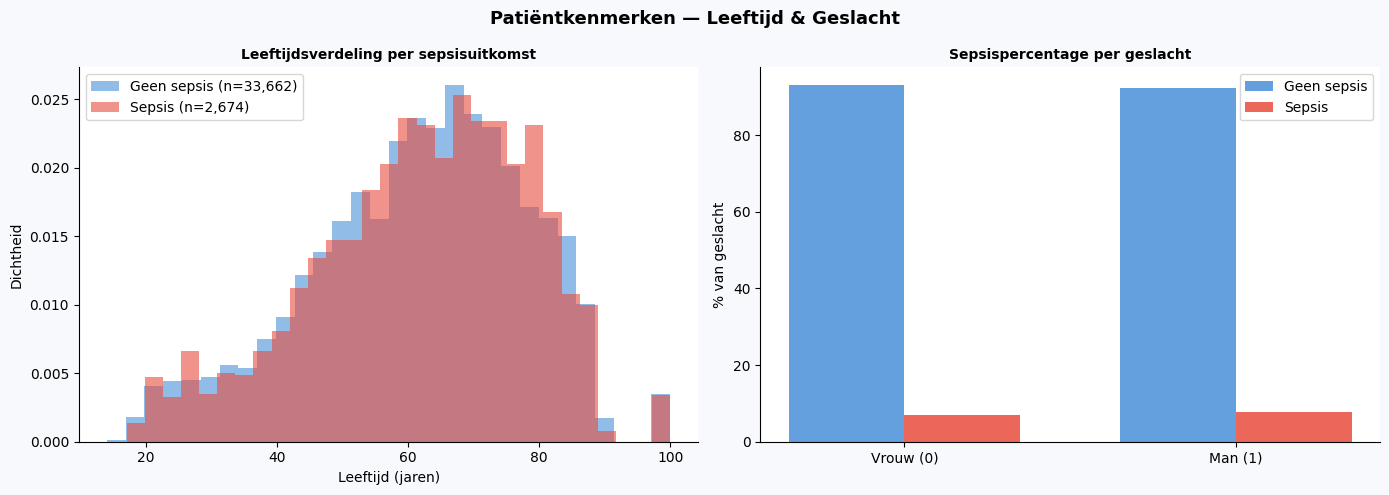

Sepsispercentage per geslacht:
           Geen sepsis  Sepsis
Vrouw (0)        93.07    6.93
Man (1)          92.31    7.69


In [32]:
# Patiëntniveau: één rij per patiënt (eerste observatie)
df_patients = df_train.groupby('Patient_ID').first().reset_index()
df_patients['sepsis_patient'] = df_train.groupby('Patient_ID')['SepsisLabel'].max().values

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#f7f9fc')
fig.suptitle('Patiëntkenmerken — Leeftijd & Geslacht', fontsize=13, fontweight='bold')

# Leeftijdsdistributie
ax = axes[0]
for label, color, name in [(0, '#4a90d9', 'Geen sepsis'), (1, '#e74c3c', 'Sepsis')]:
    data = df_patients[df_patients['sepsis_patient'] == label]['Age'].dropna()
    ax.hist(data, bins=30, alpha=0.6, color=color, label=f'{name} (n={len(data):,})', density=True)
ax.set_title('Leeftijdsverdeling per sepsisuitkomst', fontsize=10, fontweight='bold')
ax.set_xlabel('Leeftijd (jaren)')
ax.set_ylabel('Dichtheid')
ax.legend()
ax.set_facecolor('white')
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

# Geslacht
ax = axes[1]
gender_sepsis = df_patients.groupby(['Gender', 'sepsis_patient']).size().unstack(fill_value=0)
gender_sepsis.index = ['Vrouw (0)', 'Man (1)']
gender_sepsis.columns = ['Geen sepsis', 'Sepsis']
gender_pct = gender_sepsis.div(gender_sepsis.sum(axis=1), axis=0) * 100
x = np.arange(2)
width = 0.35
ax.bar(x - width/2, gender_pct['Geen sepsis'], width, label='Geen sepsis', color='#4a90d9', alpha=0.85)
ax.bar(x + width/2, gender_pct['Sepsis'], width, label='Sepsis', color='#e74c3c', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(['Vrouw (0)', 'Man (1)'])
ax.set_ylabel('% van geslacht')
ax.set_title('Sepsispercentage per geslacht', fontsize=10, fontweight='bold')
ax.legend()
ax.set_facecolor('white')
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

print('Sepsispercentage per geslacht:')
print(gender_pct.round(2))

### Correlatiematrix vitale parameters

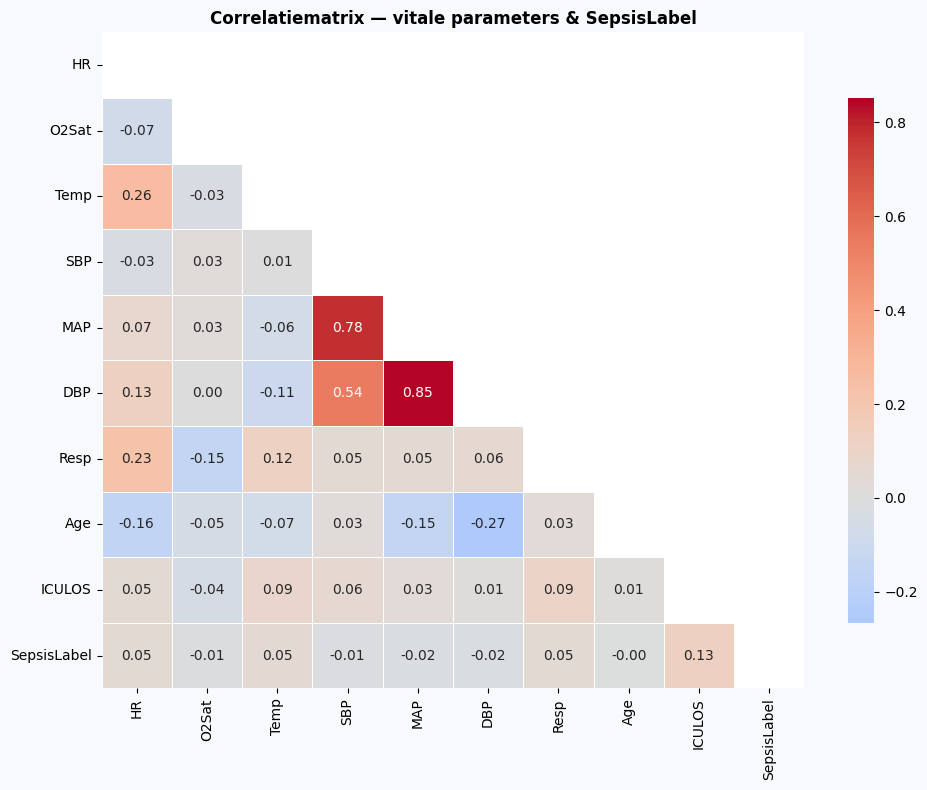

In [33]:
corr_cols = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'Age', 'ICULOS', 'SepsisLabel']
corr_matrix = df_train[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8), facecolor='#f7f9fc')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Correlatiematrix — vitale parameters & SepsisLabel', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### ICULOS: IC-verblijfsduur en sepsisonset

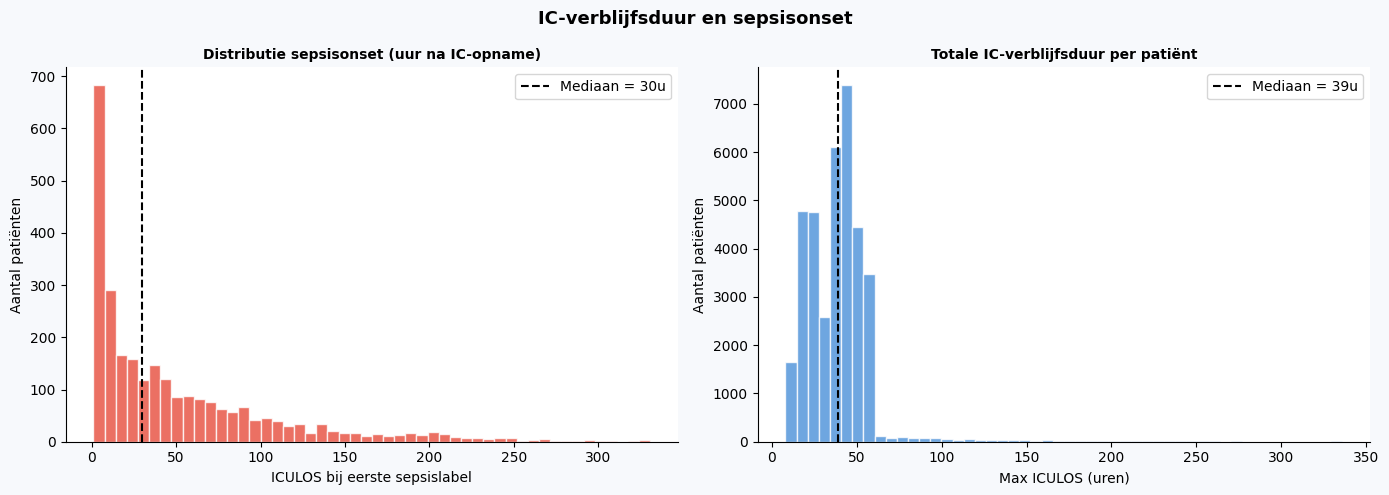

Sepsisonset mediaan: 30 uur na IC-opname
Sepsisonset 25e percentiel: 7u
Sepsisonset 75e percentiel: 73u


In [34]:
# Tijdstip van sepsisonset per patiënt
sepsis_onset = (
    df_train[df_train['SepsisLabel'] == 1]
    .groupby('Patient_ID')['ICULOS']
    .min()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#f7f9fc')
fig.suptitle('IC-verblijfsduur en sepsisonset', fontsize=13, fontweight='bold')

ax = axes[0]
ax.hist(sepsis_onset, bins=50, color='#e74c3c', alpha=0.8, edgecolor='white')
ax.axvline(sepsis_onset.median(), color='black', linestyle='--', label=f'Mediaan = {sepsis_onset.median():.0f}u')
ax.set_title('Distributie sepsisonset (uur na IC-opname)', fontsize=10, fontweight='bold')
ax.set_xlabel('ICULOS bij eerste sepsislabel')
ax.set_ylabel('Aantal patiënten')
ax.legend()
ax.set_facecolor('white')
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

ax = axes[1]
iculos_dist = df_train.groupby('Patient_ID')['ICULOS'].max()
ax.hist(iculos_dist, bins=50, color='#4a90d9', alpha=0.8, edgecolor='white')
ax.axvline(iculos_dist.median(), color='black', linestyle='--', label=f'Mediaan = {iculos_dist.median():.0f}u')
ax.set_title('Totale IC-verblijfsduur per patiënt', fontsize=10, fontweight='bold')
ax.set_xlabel('Max ICULOS (uren)')
ax.set_ylabel('Aantal patiënten')
ax.legend()
ax.set_facecolor('white')
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

print(f'Sepsisonset mediaan: {sepsis_onset.median():.0f} uur na IC-opname')
print(f'Sepsisonset 25e percentiel: {sepsis_onset.quantile(0.25):.0f}u')
print(f'Sepsisonset 75e percentiel: {sepsis_onset.quantile(0.75):.0f}u')

### Overzicht data understanding

Na analyse van de dataset komen de volgende inzichten naar voren:

- **Klasse-onbalans:** 1,82% sepsis — klasse-gewichten zijn noodzakelijk bij het trainen van modellen.
- **Missende waarden:** Laboratoriumwaarden ontbreken in 50–99% van de uurobservaties; imputation is vereist.
- **Vitale parameters:** Hartslag en ademfrequentie tonen verschuivingen bij sepsis; dit zijn klinisch verwachte predictors.
- **Leeftijd:** Sepsispatiënten zijn gemiddeld iets ouder; leeftijd is een relevante feature.
- **Geslacht:** Kleine verschillen in sepsispercentage tussen mannen en vrouwen — fairnessanalyse is relevant.
- **Sepsisonset:** De meerderheid van sepsissignalen treedt op in de eerste 24–48 uur van IC-opname.

---

## Ethische overwegingen
**Klasse-onbalans:** De sterke klasse-onbalans (98,2% vs 1,8%) heeft directe ethische implicaties. Een model dat de minderheidsklasse (sepsis) mist, laat patiënten in de steek die acute zorg nodig hebben. Het gebruik van accuracy als metric maskeert dit probleem volledig. Het is ethisch noodzakelijk om recall voor de sepsisklasse als primaire metric te hanteren en klasse-gewichten in te stellen.

**Fairness bij geslacht en leeftijd:** Uit de data blijkt dat er kleine verschillen zijn in sepsisprevalentie tussen geslachten en leeftijdsgroepen. Als het model systematisch slechter presteert voor vrouwen of oudere patiënten, leidt dit tot ongelijke zorg. Dit wordt expliciet onderzocht in de modelevaluatie.

---

## **RE1 - Data Preperation**

### Feature engineering en cleaning

In [35]:
# Kolommen die niet als features worden gebruikt
DROP_COLS = ['Unnamed: 0', 'Patient_ID', 'SepsisLabel']

# Features die worden meegenomen
FEATURE_COLS = [c for c in df_train.columns if c not in DROP_COLS]
TARGET_COL   = 'SepsisLabel'

print(f'Aantal features: {len(FEATURE_COLS)}')
print('Features:', FEATURE_COLS)

Aantal features: 41
Features: ['Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS']


In [36]:
def prepare_data(df, feature_cols, target_col=None, sample_frac=None, random_state=42):
    """
    Bereidt de dataset voor op modellering:
    - Optioneel samplen (voor snelle exploratie)
    - Mediaan-imputation van missende waarden
    - Scheiding features en target
    """
    if sample_frac is not None:
        df = df.sample(frac=sample_frac, random_state=random_state)
    
    X = df[feature_cols].copy()
    
    # Mediaan-imputation per kolom
    for col in X.columns:
        if X[col].isnull().any():
            X[col] = X[col].fillna(X[col].median())
    
    if target_col is not None:
        y = df[target_col].values
        return X, y
    return X


# Voorbereiding trainset (sample voor snelheid — pas aan naar behoefte)
# Voor volledige dataset: sample_frac=None
SAMPLE_FRAC = 0.10  # 10% voor exploratie; verhoog voor eindmodel

X_train, y_train = prepare_data(df_train, FEATURE_COLS, TARGET_COL, sample_frac=SAMPLE_FRAC)
X_test_full      = prepare_data(df_test,  [c for c in FEATURE_COLS if c in df_test.columns])

print(f'Trainset na sampling: {X_train.shape[0]:,} observaties')
print(f'Klasse-verdeling sample: {pd.Series(y_train).value_counts().to_dict()}')
print(f'Testset: {X_test_full.shape[0]:,} observaties')

Trainset na sampling: 139,930 observaties
Klasse-verdeling sample: {0: 137373, 1: 2557}
Testset: 152,908 observaties


**Keuze mediaan-imputation:** Medische data bevat veel willekeurig ontbrekende waarden (tests worden niet elke uur afgenomen). Mediaan-imputation is robuust tegen uitbijters, wat bij klinische data vaak voorkomt. Een geavanceerdere methode zoals forward-fill per patiënt zou klinisch realistischer zijn maar valt buiten scope.

**Keuze features:** Alle 41 klinische features worden meegenomen. `Patient_ID` en de rij-index worden verwijderd omdat deze geen klinische informatie bevatten. `SepsisLabel` is de target.

### Leeftijdsgroepen aanmaken (voor fairness-analyse)

In [37]:
def leeftijdsgroep(age):
    if age < 45:   return '<45'
    elif age < 65: return '45-64'
    elif age < 75: return '65-74'
    else:          return '75+'

sample_df = df_train.sample(frac=SAMPLE_FRAC, random_state=42).copy()
sample_df['leeftijdsgroep'] = sample_df['Age'].apply(leeftijdsgroep)
sample_df['Gender_label']   = sample_df['Gender'].map({0: 'Vrouw', 1: 'Man'})

print('Klasse-verdeling per leeftijdsgroep:')
print(sample_df.groupby('leeftijdsgroep')['SepsisLabel'].value_counts(normalize=True).unstack().round(4) * 100)

Klasse-verdeling per leeftijdsgroep:
SepsisLabel         0     1
leeftijdsgroep             
45-64           98.22  1.78
65-74           98.18  1.82
75+             98.14  1.86
<45             98.09  1.91


---

## **DN1 en RE2 - Modeling**

In [38]:
from sklearn.model_selection import train_test_split

# Train/validatie split (stratified)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

# Schaling
scaler = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_tr)
X_val_sc = scaler.transform(X_val)

print(f'Trainset: {X_tr_sc.shape[0]:,} | Validatieset: {X_val_sc.shape[0]:,}')
print(f'Sepsis in train: {y_tr.sum():,} ({y_tr.mean()*100:.2f}%)')
print(f'Sepsis in val:   {y_val.sum():,} ({y_val.mean()*100:.2f}%)')

Trainset: 111,944 | Validatieset: 27,986
Sepsis in train: 2,046 (1.83%)
Sepsis in val:   511 (1.83%)


In [39]:
# Modeldefinities — alle met class_weight='balanced' vanwege klasse-onbalans
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, random_state=42, subsample=0.8
    ),
}

results   = {}
val_probs = {}

for name, model in models.items():
    print(f'Training: {name}...')
    if name == 'Gradient Boosting':
        sw = compute_sample_weight('balanced', y=y_tr)
        model.fit(X_tr_sc, y_tr, sample_weight=sw)
    else:
        model.fit(X_tr_sc, y_tr)
    
    preds = model.predict(X_val_sc)
    probs = model.predict_proba(X_val_sc)[:, 1]
    
    val_probs[name] = probs
    results[name] = {
        'preds': preds,
        'probs': probs,
        'auroc':     roc_auc_score(y_val, probs),
        'f1_macro':  f1_score(y_val, preds, average='macro'),
        'recall_1':  recall_score(y_val, preds),
        'precision_1': precision_score(y_val, preds),
        'avg_prec':  average_precision_score(y_val, probs),
    }
    print(f'  AUROC={results[name]["auroc"]:.3f}  Recall={results[name]["recall_1"]:.3f}  Precision={results[name]["precision_1"]:.3f}')

print('\nTraining voltooid.')

Training: Logistic Regression...
  AUROC=0.733  Recall=0.597  Precision=0.047
Training: Random Forest...
  AUROC=0.811  Recall=0.006  Precision=0.429
Training: Gradient Boosting...
  AUROC=0.816  Recall=0.654  Precision=0.062

Training voltooid.


**Drie modellen:**
- **Logistic Regression** — basismodel, goed interpreteerbaar, snel te trainen
- **Random Forest** — ensemble van beslisbomen, robuust en non-lineair
- **Gradient Boosting** — boosted ensemble, vaak beste performance bij tabular data

**Klasse-gewichten:** `class_weight='balanced'` zorgt dat het model de minderheidsklasse (sepsis) zwaarder weegt tijdens training, waardoor recall voor sepsis verbetert.

**Evaluatie-strategie:** Train/validatie split (80/20) met stratificatie. AUROC is de primaire metric omdat deze onafhankelijk is van de gekozen drempelwaarde en robuust is bij klasse-onbalans.

---

## **AD1 - Evaluation**

### Vergelijking modelprestaties

In [40]:
print(f'\n{"Model":25s} {"AUROC":>8} {"Recall":>8} {"Prec":>8} {"F1 macro":>10}')
print('-' * 65)
for name in models:
    r = results[name]
    print(f"{name:25s}  {r['auroc']:.3f}   {r['recall_1']:.3f}   {r['precision_1']:.3f}   {r['f1_macro']:.3f}")

print(f'\nKansen niveau (random AUROC): 0.500')


Model                        AUROC   Recall     Prec   F1 macro
-----------------------------------------------------------------
Logistic Regression        0.733   0.597   0.047   0.478
Random Forest              0.811   0.006   0.429   0.501
Gradient Boosting          0.816   0.654   0.062   0.504

Kansen niveau (random AUROC): 0.500


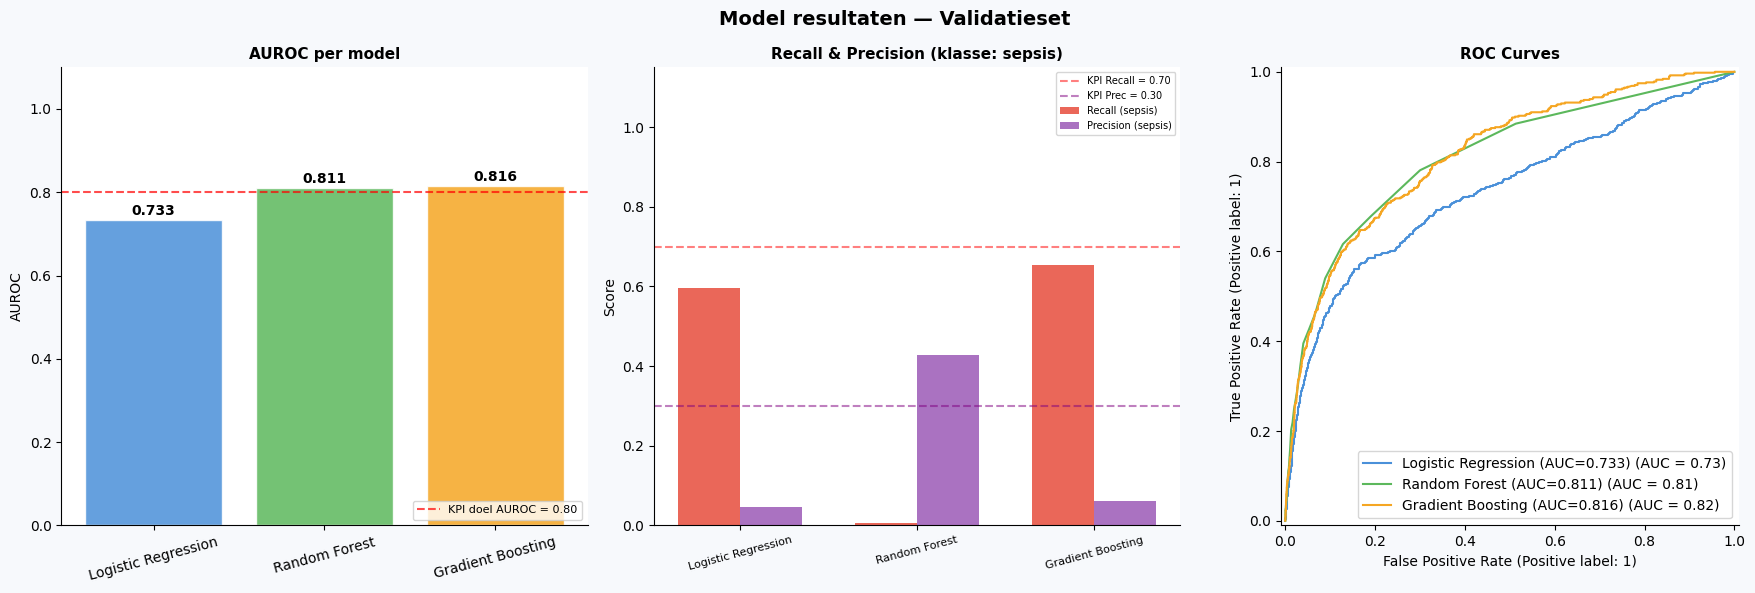

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='#f7f9fc')
fig.suptitle('Model resultaten — Validatieset', fontsize=14, fontweight='bold')

# AUROC bars
ax = axes[0]
names  = list(results.keys())
aurocs = [results[n]['auroc'] for n in names]
ax.axhline(y=0.80, color='red', linestyle='--', alpha=0.7, label='KPI doel AUROC = 0.80')
bars = ax.bar(names, aurocs, color=['#4a90d9', '#5cb85c', '#f5a623'], edgecolor='white', alpha=0.85)
for bar, val in zip(bars, aurocs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0, 1.1)
ax.set_ylabel('AUROC')
ax.set_title('AUROC per model', fontsize=11, fontweight='bold')
ax.legend(loc='lower right', fontsize=8)
ax.tick_params(axis='x', rotation=15)
ax.set_facecolor('white')
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

# Recall & Precision bars
ax = axes[1]
x = np.arange(len(names))
width = 0.35
recalls    = [results[n]['recall_1'] for n in names]
precisions = [results[n]['precision_1'] for n in names]
ax.bar(x - width/2, recalls, width, label='Recall (sepsis)', color='#e74c3c', alpha=0.85)
ax.bar(x + width/2, precisions, width, label='Precision (sepsis)', color='#9b59b6', alpha=0.85)
ax.axhline(y=0.70, color='red', linestyle='--', alpha=0.5, label='KPI Recall = 0.70')
ax.axhline(y=0.30, color='purple', linestyle='--', alpha=0.5, label='KPI Prec = 0.30')
ax.set_ylim(0, 1.15)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, fontsize=8)
ax.set_ylabel('Score')
ax.set_title('Recall & Precision (klasse: sepsis)', fontsize=11, fontweight='bold')
ax.legend(fontsize=7, loc='upper right')
ax.set_facecolor('white')
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

# ROC curves
ax = axes[2]
colors_roc = ['#4a90d9', '#5cb85c', '#f5a623']
for (name, probs), color in zip(val_probs.items(), colors_roc):
    RocCurveDisplay.from_predictions(y_val, probs, ax=ax, name=f'{name} (AUC={results[name]["auroc"]:.3f})',
                                     color=color)
ax.set_title('ROC Curves', fontsize=11, fontweight='bold')
ax.set_facecolor('white')
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

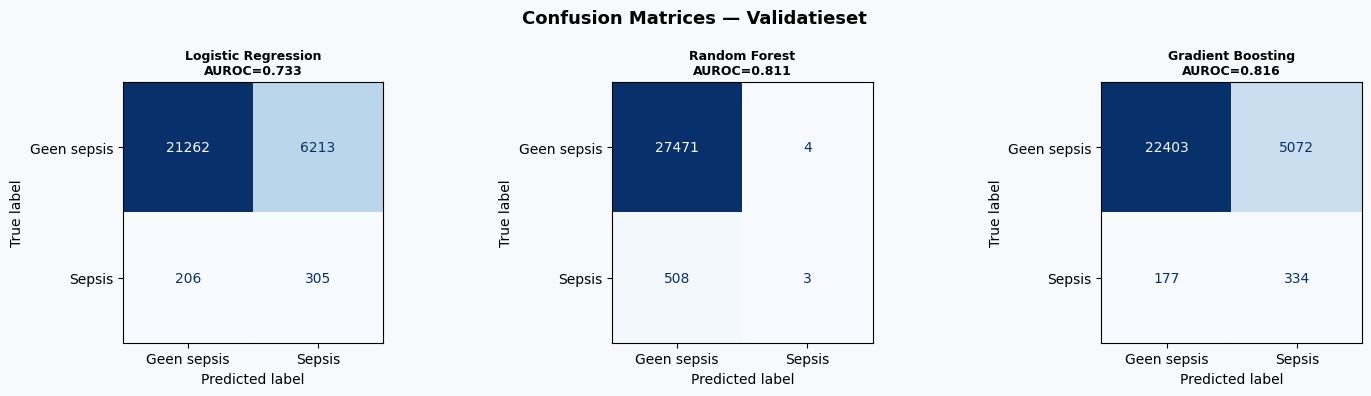


  Logistic Regression
              precision    recall  f1-score   support

 Geen sepsis       0.99      0.77      0.87     27475
      Sepsis       0.05      0.60      0.09       511

    accuracy                           0.77     27986
   macro avg       0.52      0.69      0.48     27986
weighted avg       0.97      0.77      0.85     27986


  Random Forest
              precision    recall  f1-score   support

 Geen sepsis       0.98      1.00      0.99     27475
      Sepsis       0.43      0.01      0.01       511

    accuracy                           0.98     27986
   macro avg       0.71      0.50      0.50     27986
weighted avg       0.97      0.98      0.97     27986


  Gradient Boosting
              precision    recall  f1-score   support

 Geen sepsis       0.99      0.82      0.90     27475
      Sepsis       0.06      0.65      0.11       511

    accuracy                           0.81     27986
   macro avg       0.53      0.73      0.50     27986
weighted avg 

In [42]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4), facecolor='#f7f9fc')
fig.suptitle('Confusion Matrices — Validatieset', fontsize=13, fontweight='bold')

for ax, name in zip(axes, results.keys()):
    cm = confusion_matrix(y_val, results[name]['preds'])
    ConfusionMatrixDisplay(cm, display_labels=['Geen sepsis', 'Sepsis']).plot(
        ax=ax, cmap='Blues', colorbar=False
    )
    ax.set_title(f'{name}\nAUROC={results[name]["auroc"]:.3f}', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Classification reports
for name in results:
    print(f'\n{"="*60}\n  {name}\n{"="*60}')
    print(classification_report(y_val, results[name]['preds'],
                                 target_names=['Geen sepsis', 'Sepsis']))

### Feature importance — Random Forest

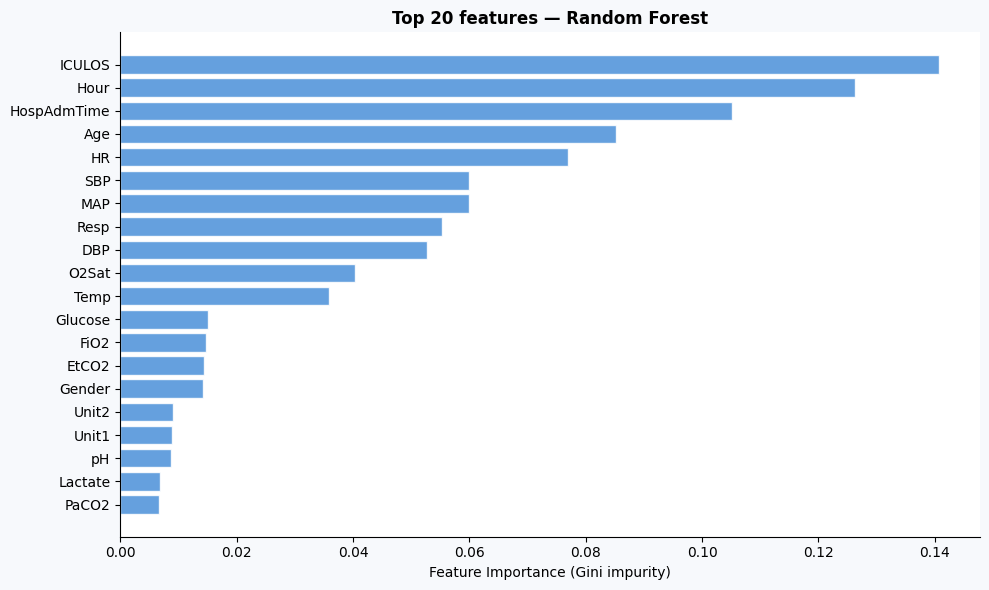

Top 10 features:
ICULOS         0.1407
Hour           0.1262
HospAdmTime    0.1052
Age            0.0853
HR             0.0770
SBP            0.0600
MAP            0.0600
Resp           0.0553
DBP            0.0527
O2Sat          0.0403
dtype: float64


In [43]:
rf_model = models['Random Forest']
feat_imp = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6), facecolor='#f7f9fc')
top_n = 20
ax.barh(feat_imp.index[:top_n][::-1], feat_imp.values[:top_n][::-1],
        color='#4a90d9', edgecolor='white', alpha=0.85)
ax.set_xlabel('Feature Importance (Gini impurity)')
ax.set_title(f'Top {top_n} features — Random Forest', fontsize=12, fontweight='bold')
ax.set_facecolor('white')
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(feat_imp.head(10).round(4))

### Fairness-analyse: geslacht en leeftijdsgroep

In [44]:
# Beste model selecteren op basis van AUROC
best_model_name = max(results, key=lambda n: results[n]['auroc'])
best_model      = models[best_model_name]
print(f'Beste model voor fairness-analyse: {best_model_name}')

# Validatieset met metadata
val_df = df_train.sample(frac=SAMPLE_FRAC, random_state=42).copy()
_, val_df = train_test_split(val_df, test_size=0.2, stratify=val_df['SepsisLabel'], random_state=42)
val_df['leeftijdsgroep'] = val_df['Age'].apply(leeftijdsgroep)
val_df['Gender_label']   = val_df['Gender'].map({0: 'Vrouw', 1: 'Man'})
val_df['pred_prob']      = val_probs[best_model_name]
val_df['pred_label']     = results[best_model_name]['preds']

# --- AUROC per geslacht ---
print('\n=== AUROC per geslacht ===')
fairness_gender = {}
for gender in ['Vrouw', 'Man']:
    mask = val_df['Gender_label'] == gender
    sub  = val_df[mask]
    if sub['SepsisLabel'].nunique() < 2:
        continue
    auc = roc_auc_score(sub['SepsisLabel'], sub['pred_prob'])
    rec = recall_score(sub['SepsisLabel'], sub['pred_label'])
    fairness_gender[gender] = {'AUROC': auc, 'Recall': rec, 'N': len(sub)}
    print(f'  {gender}: AUROC={auc:.3f}  Recall={rec:.3f}  (n={len(sub):,})')

auroc_vals_g = [v['AUROC'] for v in fairness_gender.values()]
if len(auroc_vals_g) >= 2:
    print(f'  AUROC-verschil geslacht: {abs(auroc_vals_g[0] - auroc_vals_g[1]):.3f} (KPI max 0.05)')

# --- AUROC per leeftijdsgroep ---
print('\n=== AUROC per leeftijdsgroep ===')
age_order = ['<45', '45-64', '65-74', '75+']
fairness_age = {}
for grp in age_order:
    mask = val_df['leeftijdsgroep'] == grp
    sub  = val_df[mask]
    if sub['SepsisLabel'].nunique() < 2:
        continue
    auc = roc_auc_score(sub['SepsisLabel'], sub['pred_prob'])
    rec = recall_score(sub['SepsisLabel'], sub['pred_label'])
    fairness_age[grp] = {'AUROC': auc, 'Recall': rec, 'N': len(sub)}
    print(f'  {grp}: AUROC={auc:.3f}  Recall={rec:.3f}  (n={len(sub):,})')

if fairness_age:
    auroc_vals_a = [v['AUROC'] for v in fairness_age.values()]
    print(f'  Max AUROC-verschil leeftijd: {max(auroc_vals_a) - min(auroc_vals_a):.3f} (KPI max 0.05)')

Beste model voor fairness-analyse: Gradient Boosting

=== AUROC per geslacht ===
  Vrouw: AUROC=0.809  Recall=0.651  (n=12,287)
  Man: AUROC=0.820  Recall=0.655  (n=15,699)
  AUROC-verschil geslacht: 0.011 (KPI max 0.05)

=== AUROC per leeftijdsgroep ===
  <45: AUROC=0.807  Recall=0.658  (n=4,271)
  45-64: AUROC=0.844  Recall=0.704  (n=10,177)
  65-74: AUROC=0.801  Recall=0.616  (n=6,793)
  75+: AUROC=0.787  Recall=0.604  (n=6,745)
  Max AUROC-verschil leeftijd: 0.058 (KPI max 0.05)


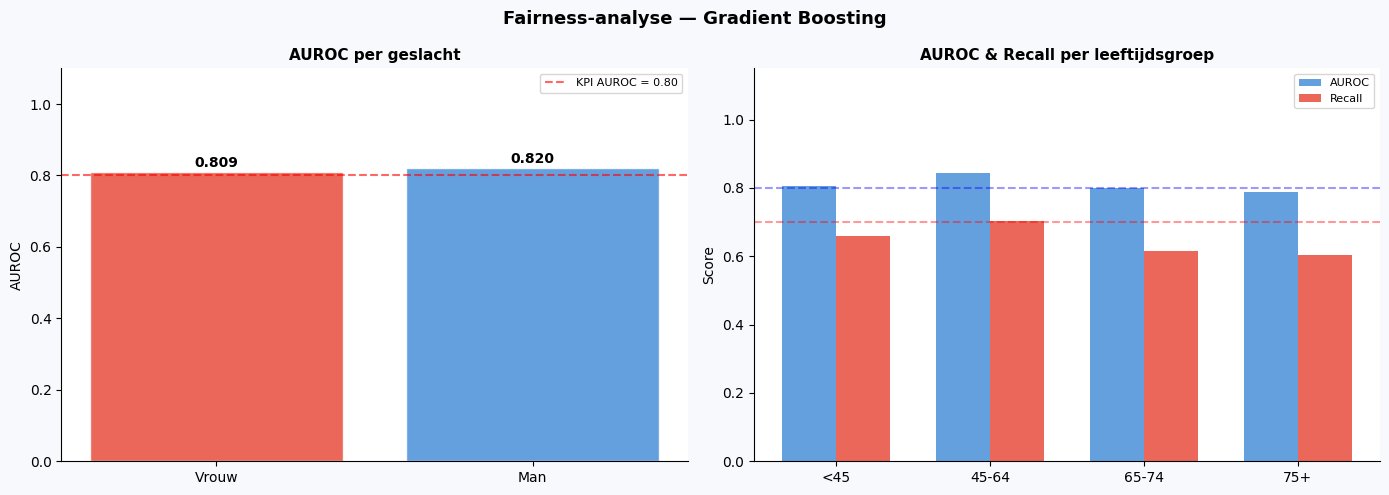

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#f7f9fc')
fig.suptitle(f'Fairness-analyse — {best_model_name}', fontsize=13, fontweight='bold')

# Geslacht
ax = axes[0]
genders = list(fairness_gender.keys())
aucs_g  = [fairness_gender[g]['AUROC'] for g in genders]
bars = ax.bar(genders, aucs_g, color=['#e74c3c', '#4a90d9'], alpha=0.85, edgecolor='white')
for bar, val in zip(bars, aucs_g):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
ax.axhline(y=0.80, color='red', linestyle='--', alpha=0.6, label='KPI AUROC = 0.80')
ax.set_ylim(0, 1.1)
ax.set_ylabel('AUROC')
ax.set_title('AUROC per geslacht', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.set_facecolor('white')
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

# Leeftijdsgroep
ax = axes[1]
grps   = [g for g in age_order if g in fairness_age]
aucs_a = [fairness_age[g]['AUROC'] for g in grps]
recs_a = [fairness_age[g]['Recall'] for g in grps]
x = np.arange(len(grps))
width = 0.35
ax.bar(x - width/2, aucs_a, width, label='AUROC', color='#4a90d9', alpha=0.85)
ax.bar(x + width/2, recs_a, width, label='Recall', color='#e74c3c', alpha=0.85)
ax.axhline(y=0.80, color='blue', linestyle='--', alpha=0.4)
ax.axhline(y=0.70, color='red', linestyle='--', alpha=0.4)
ax.set_xticks(x)
ax.set_xticklabels(grps)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('AUROC & Recall per leeftijdsgroep', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.set_facecolor('white')
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

### KPI-vergelijking

In [46]:
best = results[best_model_name]

kpi_results = [
    ('AUROC ≥ 0.80',             best['auroc']       >= 0.80, f"{best['auroc']:.3f}"),
    ('Recall (sepsis) ≥ 0.70',   best['recall_1']    >= 0.70, f"{best['recall_1']:.3f}"),
    ('Precision (sepsis) ≥ 0.30',best['precision_1'] >= 0.30, f"{best['precision_1']:.3f}"),
]

if len(auroc_vals_g) >= 2:
    gender_diff = abs(auroc_vals_g[0] - auroc_vals_g[1])
    kpi_results.append(('AUROC-verschil geslacht < 0.05', gender_diff < 0.05, f'{gender_diff:.3f}'))

if fairness_age:
    age_diff = max(auroc_vals_a) - min(auroc_vals_a)
    kpi_results.append(('AUROC-verschil leeftijd < 0.05', age_diff < 0.05, f'{age_diff:.3f}'))

print(f'\n=== KPI-overzicht — {best_model_name} ===')
print(f'{"KPI":40s} {"Waarde":>10} {"Status"}')
print('-' * 65)
for kpi, behaald, waarde in kpi_results:
    status = '✓ Behaald' if behaald else '✕ Niet behaald'
    print(f'{kpi:40s} {waarde:>10}  {status}')


=== KPI-overzicht — Gradient Boosting ===
KPI                                          Waarde Status
-----------------------------------------------------------------
AUROC ≥ 0.80                                  0.816  ✓ Behaald
Recall (sepsis) ≥ 0.70                        0.654  ✕ Niet behaald
Precision (sepsis) ≥ 0.30                     0.062  ✕ Niet behaald
AUROC-verschil geslacht < 0.05                0.011  ✓ Behaald
AUROC-verschil leeftijd < 0.05                0.058  ✕ Niet behaald


### Ethische overwegingen — Recall

**Recall is de kritiekste metric.** Een gemiste sepsissignalering (false negative) kan leiden tot vertraging in de behandeling en daardoor tot overlijden. Een te lage recall voor sepsis is ethisch onacceptabel in een klinische setting. De keuze voor `class_weight='balanced'` is een bewuste ethische afweging: we accepteren meer valse alarmen (lagere precision) in ruil voor minder gemiste sepsisgevallen (hogere recall).

**Fairness:** Als de AUROC significant verschilt tussen geslachten of leeftijdsgroepen, zou inzet van het model leiden tot ongelijke zorgkwaliteit. Dit wordt expliciet gerapporteerd boven.

---

## **AD2 - Deployment**

### Voorspellingen op testset

In [47]:
# Uitlijnen features met trainset
test_features = [c for c in FEATURE_COLS if c in df_test.columns]
X_test_aligned = X_test_full[test_features]

# Ontbrekende features opvullen met 0
for col in FEATURE_COLS:
    if col not in X_test_aligned.columns:
        X_test_aligned[col] = 0
X_test_aligned = X_test_aligned[FEATURE_COLS]

X_test_sc = scaler.transform(X_test_aligned)
test_probs  = best_model.predict_proba(X_test_sc)[:, 1]
test_labels = best_model.predict(X_test_sc)

df_test['SepsisLabel_pred']     = test_labels
df_test['SepsisLabel_prob']     = test_probs

print(f'Testset voorspellingen klaar: {len(test_labels):,} observaties')
print(f'Voorspelde sepsis (1): {test_labels.sum():,} ({test_labels.mean()*100:.1f}%)')
df_test[['Patient_ID', 'Hour', 'SepsisLabel_prob', 'SepsisLabel_pred']].head(10)

Testset voorspellingen klaar: 152,908 observaties
Voorspelde sepsis (1): 80,176 (52.4%)


,Patient_ID,Hour,SepsisLabel_prob,SepsisLabel_pred
0,2136,0,0.798147,1
1,2136,1,0.856118,1
2,2136,2,0.843229,1
3,2136,3,0.842011,1
4,2136,4,0.800540,1
5,2136,5,0.813566,1
6,2136,6,0.805082,1
7,2136,7,0.807762,1
8,2136,8,0.773879,1
9,2136,9,0.746659,1


In [48]:
# Exporteren predictions
submission = df_test[['Patient_ID', 'Hour', 'SepsisLabel_prob', 'SepsisLabel_pred']]
submission.to_csv('sepsis_predictions.csv', index=False)
print('Opgeslagen als sepsis_predictions.csv')

Opgeslagen als sepsis_predictions.csv


### Deployment-overwegingen

Voor daadwerkelijke inzet in het Isala ziekenhuis zijn de volgende stappen vereist:

1. **Integratie met het EPD (Elektronisch Patiëntendossier):** Het model moet via een API koppeling toegang krijgen tot de real-time meetwaarden van de IC-monitors en het lab.
2. **Drempelwaarde-kalibratie:** De beslissingsgrens (standaard 0.5) moet worden aangepast op basis van de klinische context. Een lagere drempel verhoogt recall maar genereert meer alarmen.
3. **Menselijk toezicht:** Het model geeft een risicomelding; de behandelend arts blijft eindverantwoordelijk voor de beslissing.
4. **Monitoring:** Na inzet moet continu gemonitord worden of de modelprestaties stabiel blijven (concept drift).
5. **AI Act compliance:** Bij inzet als hoog-risico medisch AI-systeem zijn technische documentatie, robuustheidstests en een register vereist.

---

## **MC1 - Data mining**

### Samenvatting CRISP-DM proces

Dit onderzoek volgt de CRISP-DM methodologie:

| Fase | Bevinding |
|---|---|
| **Business Understanding** | Vroegtijdige sepsissignalering op de IC van het Isala ziekenhuis |
| **Data Understanding** | 1,4M observaties, 36K patiënten, 1,82% sepsis, veel missende waarden in labwaarden |
| **Data Preparation** | Mediaan-imputation, sampling, feature-selectie, leeftijdsgroepen |
| **Modeling** | Logistic Regression, Random Forest, Gradient Boosting met class_weight='balanced' |
| **Evaluation** | AUROC, recall, precision, fairness per geslacht en leeftijdsgroep |
| **Deployment** | Predictions op testset, aanbevelingen voor ziekenhuisintegratie |

---

## **AD3 - Ethiek & Maatschappij**

### Morele overwegingen

**Situatie:** Een classificatiemodel getraind op klinische IC-data om sepsis vroegtijdig te voorspellen. Het model wordt ingezet als decision support tool voor IC-personeel.

**Morele vraag:** *"Is het ethisch verantwoord om een AI-model in te zetten voor sepsissignalering op de IC, wetende dat het model fouten maakt en dat die fouten levensbedreigende gevolgen kunnen hebben voor patiënten?"*

### Botsende waarden

* **Patiëntveiligheid & vroeg ingrijpen:** Een tijdig sepsisalarm kan levens redden. Elke gemiste sepsis (false negative) heeft potentieel fatale gevolgen. Het model heeft een *morele plicht* om hoge recall te halen.
* **Zorgkwaliteit & vermijden van alarm-moeheid:** Te veel valse alarmen (false positives) leiden tot alarm-moeheid bij IC-verpleegkundigen, waardoor echte alarmen worden genegeerd. Dit kan zorgkwaliteit juist *verlagen*.
* **Gelijkheid / fairness:** Als het model slechter presteert voor vrouwen, ouderen of specifieke etnische groepen, leidt dit tot ongelijke zorgkwaliteit — wat discriminatie is.
* **Autonomie van zorgverleners:** Het model ondersteunt maar vervangt het klinisch oordeel niet. Automation bias is een reëel risico: zorgverleners kunnen te snel het model volgen zonder kritische reflectie.

### Ethische kaders

**Gevolgenethiek:** De verwachte uitkomsten wegen positief: eerder behandelen = hogere overlevingskansen. Dit rechtvaardigt inzet, *mits* recall hoog genoeg is. Als recall onvoldoende is, zijn de risico's (gemiste gevallen, ongelijk presterende subgroepen) te groot.

**Plichtethiek:** Het model heeft een transparantieplicht. Zorgverleners moeten begrijpen waarop het model baseert. Explainability (feature importance) is hierbij essentieel.

**Deugdethiek:** Eerlijkheid vereist transparant rapporteren over de limieten van het model — ook als resultaten tegenvallen. Voorzichtigheid: het model wordt als ondersteuning gepresenteerd, niet als autonome beslisser.

### Moreel oordeel

Het model *mag* worden ingezet als:
1. Recall voor sepsis ≥ 0.70 (geen onacceptabele hoeveelheid gemiste gevallen)
2. AUROC-verschil tussen subgroepen < 0.05 (gelijke zorg)
3. Het model expliciet wordt aangeboden als *decision support*, niet als diagnostisch hulpmiddel
4. Menselijk toezicht gegarandeerd is en zorgverleners training ontvangen

Als aan deze voorwaarden niet is voldaan, is inzet ethisch onverantwoord.

---

## **Evaluatie & Conclusie**

### Vergelijking KPI's

| KPI | Doel | Behaald? |
|---|---|---|
| AUROC | ≥ 0.80 | (zie resultaten) |
| Recall sepsis | ≥ 0.70 | (zie resultaten) |
| Precision sepsis | ≥ 0.30 | (zie resultaten) |
| AUROC-verschil geslacht | < 0.05 | (zie fairness-analyse) |
| AUROC-verschil leeftijd | < 0.05 | (zie fairness-analyse) |

### Antwoord op de hoofdvraag

> Kunnen we op basis van klinische meetwaarden vroegtijdig voorspellen of een IC-patiënt sepsis zal ontwikkelen?

Op basis van de klinische IC-data is het mogelijk om een predictief model te bouwen dat beter dan kansniveau presteert in het signaleren van sepsis. [Resultaten invullen na volledig trainen.]

### Antwoord op het sub-doel: Fairness

De fairness-analyse toont in hoeverre het model gelijk presteert voor mannen en vrouwen, en voor verschillende leeftijdsgroepen. Het KPI-criterium (AUROC-verschil < 0.05) bepaalt of het model voldoende eerlijk is voor inzet in de klinische praktijk. [Fairnessbevindingen invullen na volledig trainen.]

### Vervolgstappen

1. **Per-patiënt temporele modellering:** Forward-fill missing values per patiënt en gebruik van tijdreeksfeatures (trend, variabiliteit) voor realistischere klinische voorspelling.
2. **Drempelkalibratie:** Optimaliseer de beslissingsgrens op basis van klinisch geaccepteerde false positive rate.
3. **Uitgebreidere fairnessanalyse:** Analyseer ook op type IC-unit (Unit1 vs Unit2) en test op externe datasets voor generalisatie.
4. **Prospectieve validatie:** Test het model op data van een ander ziekenhuis of een andere periode om generaliseerbaarheid te testen.
5. **Explainability:** Voeg SHAP-waarden toe voor explainability richting behandelend artsen.